# Exploratory Data Analysis: Kenyan Public Service Announcements (PSAs)
### Multilingual dataset — English, Kiswahili, Ekegusii

This notebook performs a complete EDA on `Final_merged_psas.csv`, a corpus of Public Service Announcements (PSAs) translated across three languages and tagged by policy domain. Every analysis section is followed by a written **Interpretation** cell explaining what the result means and why it matters (e.g., for downstream NLP/MT modeling, data cleaning, or reporting).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

df = pd.read_csv('Final_merged_psas.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 21306 rows x 5 columns


,PSA_ID,Domain,English,Kiswahili,Ekegusii
0,1,Agriculture,Farmers are urged to prioritize safe agrochemical usage as Kenya hosts the World Farmers' Organisation General Assem...,Wakulima wanakumbushwa kuzingatia matumizi salama ya kemikali za kilimo wakati Kenya ikihudumia Mkutano Mkuu wa Shir...,Abakuli batosere omogori bw'ogenda gesia bw'ogenda buya bw'ekegero naki bwasibori weke umwaki wa World Farmers' Orga...
1,2,Agriculture,Trucks ferrying top-dressing fertilizer are now arriving at the Eldoret Depot of the National Cereals and Produce Bo...,Masafa yanayosafirisha mbolea ya kuongeza mavuno sasa yanawasili katika Ghala la Eldoret la Bodi ya Taifa ya Nafaka ...,Matika agwanana oria okora buya bwakonyang'ana oria buye bwanyama bwanja buya bu fei na Eldoret ya National Cereals ...
2,3,Agriculture,Farmers in Wajir are invited to participate in the Ksh. 5 billion Livestock Investment Drive launched by President R...,Wakulima wa Wajir wanakaribishwa kushiriki katika Mpango wa Uwekezaji wa Mifugo wa Ksh. bilioni 5 ulioanzishwa na Ra...,Abagere bu Wajir batarikire kugana mu Ksh. 5 billion Livestock Investment Drive amogotere President Ruto.
3,4,Agriculture,Farmers are encouraged to participate in the sugarcane ethanol initiative to help lower fuel prices and boost the su...,Wakulima wanahimizwa kushiriki katika mpango wa etanoli wa miwa ili kusaidia kupunguza bei ya mafuta na kuimarisha s...,Abagaba batemerewe kuhakanya mulashi wa ethanol ya miwa kugira akore bajua ng'ana buya na bushande bw'ekisukari.
4,5,Agriculture,"A Ksh. 34.4 billion program has been launched to enhance climate resilience, food security, and sustainable liveliho...","Mpango wa Ksh. bilioni 34.4 umeanzishwa ili kuimarisha ustahimilivu wa hali ya hewa, usalama wa chakula, na maisha e...","Programu ya Ksh. 34.4 bilioni imeanzishwa kuimarisha ustahimilivu wa hali ya hewa, usalama wa chakula, na maisha end..."


**Interpretation:** The dataset contains **21,306 rows** and **5 columns**: `PSA_ID`, `Domain`, `English`, `Kiswahili`, and `Ekegusii`. Each row is a single PSA message that has been authored/translated in parallel across the three languages, with a categorical `Domain` label describing the policy area (e.g. Agriculture, Health). This structure suggests the dataset is intended for multilingual NLP work — such as machine translation, text classification, or cross-lingual embedding evaluation.

## 1. Data Structure & Types

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21306 entries, 0 to 21305
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   PSA_ID     21306 non-null  str  
 1   Domain     21306 non-null  str  
 2   English    21306 non-null  str  
 3   Kiswahili  21303 non-null  str  
 4   Ekegusii   21306 non-null  str  
dtypes: str(5)
memory usage: 832.4 KB


**Interpretation:** All five columns are stored as text (`object`/string) — including `PSA_ID`, which is *not* a clean integer. This is an early signal (confirmed below) that `PSA_ID` mixes numeric and alphanumeric identifiers, and should not be treated as a simple auto-incrementing key without further cleaning.

## 2. Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary

,missing_count,missing_pct
PSA_ID,0,0.00
Domain,0,0.00
English,0,0.00
Kiswahili,3,0.01
Ekegusii,0,0.00


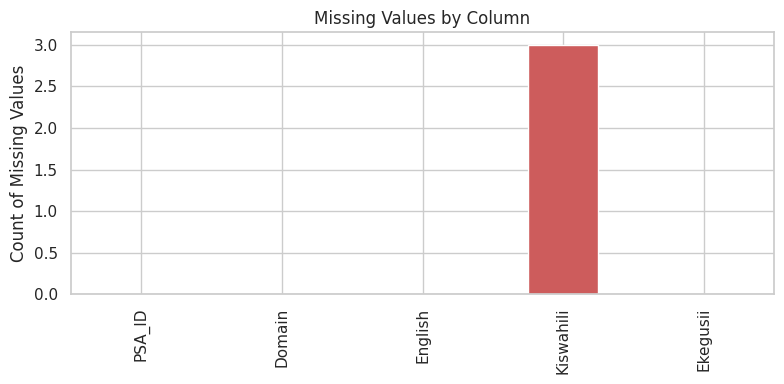

In [4]:
fig, ax = plt.subplots(figsize=(8,4))
missing_summary['missing_count'].plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Missing Values by Column')
ax.set_ylabel('Count of Missing Values')
plt.tight_layout()
plt.show()

**Interpretation:** Missingness is extremely low: only **3 rows (0.01%)** are missing a `Kiswahili` translation, and `English`, `Ekegusii`, `Domain`, and `PSA_ID` are fully populated. This is a very clean dataset overall — the missing Kiswahili rows can either be dropped or manually back-filled from the English/Ekegusii text depending on downstream use (e.g., they'd need to be excluded from any Kiswahili-specific language model training).

## 3. Identifier Integrity & Duplicates

In [5]:
print("Duplicate full rows:", df.duplicated().sum())
print("Duplicate PSA_ID values (raw):", df['PSA_ID'].duplicated().sum())
print("Duplicate (PSA_ID, Domain) pairs:", df.duplicated(subset=['PSA_ID','Domain']).sum())
print("Duplicate English messages:", df['English'].duplicated().sum())
print()
print("Sample of PSA_ID values reused across different domains:")
dup_ids = df[df['PSA_ID'].duplicated(keep=False)].sort_values('PSA_ID')
dup_ids[['PSA_ID','Domain','English']].head(6)

Duplicate full rows: 0
Duplicate PSA_ID values (raw): 462
Duplicate (PSA_ID, Domain) pairs: 0
Duplicate English messages: 0

Sample of PSA_ID values reused across different domains:


,PSA_ID,Domain,English
0,1,Agriculture,Farmers are urged to prioritize safe agrochemical usage as Kenya hosts the World Farmers' Organisation General Assem...
16327,1,Education,"Introduces a multimodal AI pipeline that processes spoken English through speech-to-text, converts it into American ..."
16336,10,Education,Target to increase school feeding beneficiaries from 1.9 million to over 10 million children by 2030
8,10,Agriculture,The Kenya Sugar Board announces that no sugar factories have been sold; they are only leased. Stakeholders should ve...
16426,100,Education,Be vigilant! Report school fee fraud to authorities.
89,100,Agriculture,Farmers are encouraged to hire qualified irrigation technicians with proven experience for drip irrigation system in...


**Interpretation:** There are **no fully duplicated rows** and **no duplicate English messages** — every PSA text is unique. However, **462 `PSA_ID` values are reused** across different domains (e.g., `PSA_ID = 1` exists for both Agriculture and Education). This happens because IDs are **numbered independently within each domain** rather than globally. The true unique key for this dataset is the **composite (`PSA_ID`, `Domain`)** pair, which has zero duplicates. Any join, merge, or lookup logic built on `PSA_ID` alone would silently produce incorrect results — this is an important data-integrity finding for anyone building on this dataset.

In [6]:
# Confirm the ID pattern: are there alphanumeric IDs too?
non_numeric_ids = df[~df['PSA_ID'].astype(str).str.fullmatch(r'\d+')]
print(f"Non purely-numeric PSA_IDs: {len(non_numeric_ids)}")
non_numeric_ids['PSA_ID'].unique()[:10]

Non purely-numeric PSA_IDs: 15865


<StringArray>
['HEA_00001', 'HEA_00002', 'HEA_00003', 'HEA_00004', 'HEA_00005', 'HEA_00006',
 'HEA_00007', 'HEA_00008', 'HEA_00009', 'HEA_00010']
Length: 10, dtype: str

**Interpretation:** Beyond the numeric IDs, a subset of PSA_IDs follow an alphanumeric convention (e.g. prefixed identifiers like `SEC_03017`), evidently used for the "Security" domain specifically. This confirms IDs are domain-scoped label sequences rather than a single global numbering scheme, reinforcing the composite-key finding above.

## 4. Domain (Category) Distribution

In [7]:
domain_counts = df['Domain'].value_counts()
domain_pct = (domain_counts / len(df) * 100).round(1)
pd.DataFrame({'count': domain_counts, 'pct': domain_pct})

,count,pct
Domain,,
Education,5288,24.8
Agriculture,4456,20.9
Health,4088,19.2
Governance,3460,16.2
Security & Safety,3017,14.2
Security,997,4.7


/tmp/ipykernel_601/3833839409.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[0], palette='viridis')


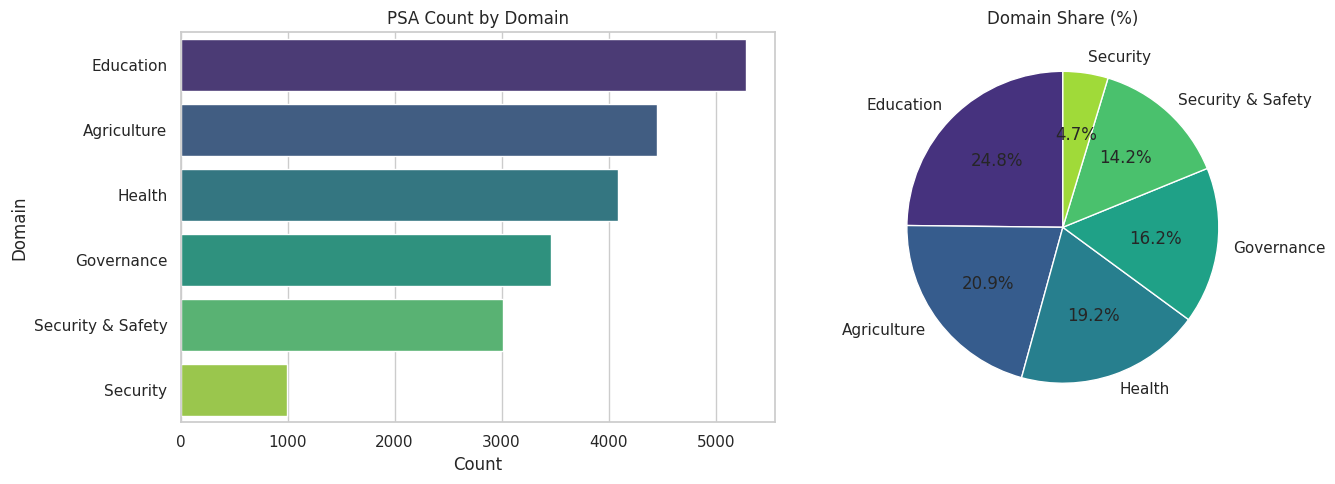

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('PSA Count by Domain')
axes[0].set_xlabel('Count')

axes[1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', len(domain_counts)))
axes[1].set_title('Domain Share (%)')
plt.tight_layout()
plt.show()

**Interpretation:** The dataset spans **6 domain categories**, with **Education (24.8%)**, **Agriculture (20.9%)**, and **Health (19.2%)** as the largest, and **Security (4.7%)** as by far the smallest. Notably, there are *two* related-but-distinct labels — `Security` and `Security & Safety` (997 vs 3,017 rows) — which are likely candidates for **merging into a single category** during any classification task, since they probably represent overlapping or inconsistently-applied labeling rather than truly distinct classes. This should be verified by reading a sample of each before merging.

In [9]:
print("Sample 'Security' rows:")
print(df[df['Domain']=='Security']['English'].head(3).to_string())
print()
print("Sample 'Security & Safety' rows:")
print(df[df['Domain']=='Security & Safety']['English'].head(3).to_string())

Sample 'Security' rows:
18616    Floods are common in Kenya during rainy seasons. Learn evacuation routes, store emergency supplies, and avoid floode...
18617    Informal settlements are prone to fires due to congested housing and illegal electricity connections. Report hazards...
18618    Droughts devastate livestock and livelihoods. The government provides water trucking and livestock feeds. Report sev...

Sample 'Security & Safety' rows:
9480    Kenya Red Cross reminds residents of Bungoma County to heed evacuation orders issued by local administrators during ...
9481    NPS reminds residents of Laikipia County to install and maintain fire extinguishers at home and work during this flo...
9482      Notice: Directorate of Criminal Investigations activates an emergency response plan for landslides in Kajiado County.


**Interpretation:** Reviewing the raw text confirms both labels cover similar thematic ground (public safety, crime, emergency response), supporting the recommendation above to treat `Security` and `Security & Safety` as a single merged class for modeling purposes, while preserving the original labels for traceability.

## 5. Text Length Analysis (Word & Character Counts)

In [10]:
for col in ['English', 'Kiswahili', 'Ekegusii']:
    df[f'{col}_word_count'] = df[col].astype(str).str.split().str.len()
    df[f'{col}_char_count'] = df[col].astype(str).str.len()

length_stats = pd.DataFrame({
    'English_words': df['English_word_count'].describe(),
    'Kiswahili_words': df['Kiswahili_word_count'].describe(),
    'Ekegusii_words': df['Ekegusii_word_count'].describe(),
    'English_chars': df['English_char_count'].describe(),
    'Kiswahili_chars': df['Kiswahili_char_count'].describe(),
    'Ekegusii_chars': df['Ekegusii_char_count'].describe(),
}).T
length_stats.round(1)

,count,mean,std,min,25%,50%,75%,max
English_words,21306.0,18.5,6.0,1.0,15.0,18.0,22.0,109.0
Kiswahili_words,21303.0,21.9,7.7,1.0,18.0,22.0,26.0,340.0
Ekegusii_words,21306.0,19.8,6.4,2.0,16.0,19.0,23.0,101.0
English_chars,21306.0,124.3,39.3,12.0,99.0,123.0,145.0,718.0
Kiswahili_chars,21303.0,139.3,45.9,14.0,114.0,138.0,164.0,1697.0
Ekegusii_chars,21306.0,144.8,47.1,15.0,115.0,140.0,168.0,752.0


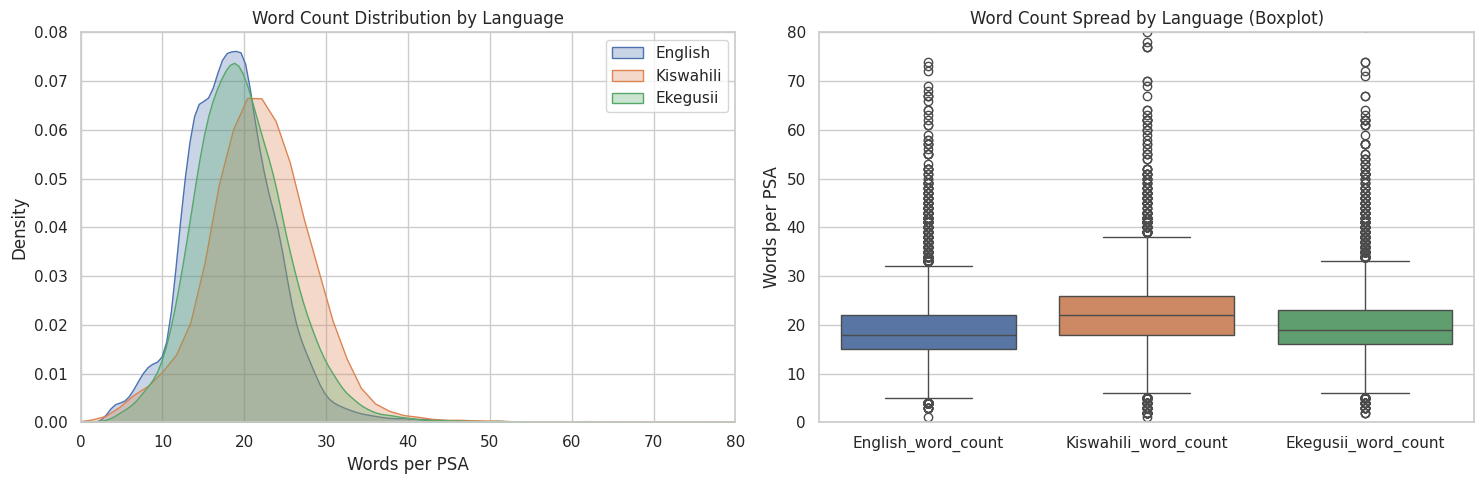

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
for col, color in zip(['English','Kiswahili','Ekegusii'], ['#4C72B0','#DD8452','#55A868']):
    sns.kdeplot(df[f'{col}_word_count'], ax=axes[0], label=col, fill=True, alpha=0.3, color=color)
axes[0].set_title('Word Count Distribution by Language')
axes[0].set_xlabel('Words per PSA')
axes[0].set_xlim(0, 80)
axes[0].legend()

sns.boxplot(data=df[['English_word_count','Kiswahili_word_count','Ekegusii_word_count']], ax=axes[1], palette=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Word Count Spread by Language (Boxplot)')
axes[1].set_ylabel('Words per PSA')
axes[1].set_ylim(0, 80)
plt.tight_layout()
plt.show()

**Interpretation:** Kiswahili messages are consistently the **longest** (mean ≈ 21.9 words / 139 chars), followed by Ekegusii (≈19.8 words / 145 chars), with English the **most concise** (≈18.5 words / 124 chars). This is linguistically expected: Bantu languages like Kiswahili and Ekegusii often require more words/morphemes to express the same meaning as English due to agglutinative grammar and noun-class prefixing. The word-count distributions are right-skewed (long tail of longer PSAs) but the vast majority of messages sit between 10–30 words — a fairly narrow, consistent "PSA-length" style across all three languages. This consistency is good news for translation-quality/alignment work, since wildly divergent lengths would suggest mistranslation or missing segments.

       ratio_kis_eng  ratio_ekg_eng
count       21303.00       21306.00
mean            1.20           1.10
std             0.29           0.29
min             0.23           0.23
25%             1.10           0.94
50%             1.20           1.06
75%             1.31           1.21
max            28.33           6.38


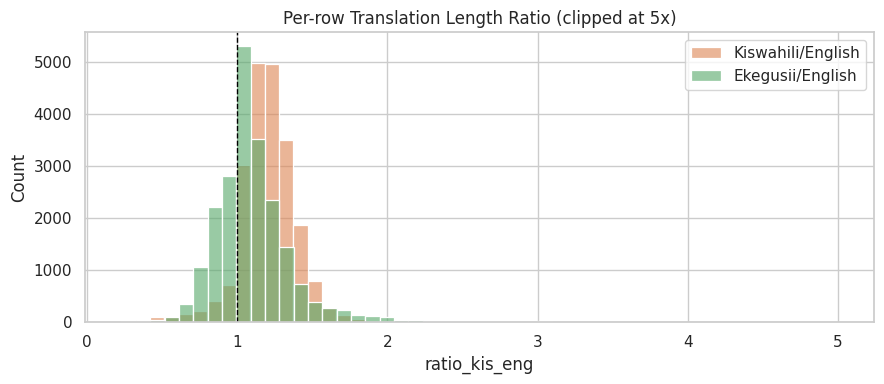

In [12]:
# Length ratio sanity check: Kiswahili/Ekegusii word count relative to English, per row
df['ratio_kis_eng'] = df['Kiswahili_word_count'] / df['English_word_count']
df['ratio_ekg_eng'] = df['Ekegusii_word_count'] / df['English_word_count']

print(df[['ratio_kis_eng','ratio_ekg_eng']].describe().round(2))

fig, ax = plt.subplots(figsize=(9,4))
sns.histplot(df['ratio_kis_eng'].clip(0,5), bins=50, color='#DD8452', label='Kiswahili/English', alpha=0.6)
sns.histplot(df['ratio_ekg_eng'].clip(0,5), bins=50, color='#55A868', label='Ekegusii/English', alpha=0.6)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Per-row Translation Length Ratio (clipped at 5x)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The median length ratio for both languages sits just above 1.0, confirming translations are proportionate to their English source on a per-row basis, not just in aggregate. A small number of rows show extreme ratios (>3–5x) — these are worth flagging as **potential translation quality outliers** (e.g., a translator adding explanatory context, or a data-entry error pasting the wrong text) and could be spot-checked before using the data for MT model training.

In [13]:
# Flag extreme outlier rows for inspection
outliers = df[(df['ratio_kis_eng'] > 4) | (df['ratio_ekg_eng'] > 4)]
print(f"Rows with >4x length ratio: {len(outliers)}")
outliers[['PSA_ID','Domain','English','Kiswahili']].head(5)

Rows with >4x length ratio: 17


,PSA_ID,Domain,English,Kiswahili
2350,HEA_01889,Health,Kenya Red Cross reminds the public that free depression awareness support is available through county health facilit...,Mauzo ya Msalaba Mwekundu wa Kenya yanakumbusha umma kwamba msaada wa kujitambua kwa huzuni bure upatikana kupitia v...
2368,HEA_01907,Health,SHA (Social Health Authority) urges anyone struggling with their mental health in Meru County to call the toll-free ...,SHA (Mamlaka ya Afya ya Kijamii) inawahimiza wale wote wanaokabiliana na matatizo ya afya ya akili katika Kaunti ya ...
4671,AGR_01192,Agriculture,Agriculture and Food Authority (AFA) announces a free anthrax vaccination exercise for cattle in Meru County this July.,Mamlaka ya Kilimo na Chakula (AFA) yatangaza zoezi la chanjo ya bure ya anthrax kwa ng'ombe katika Kaunti ya Meru mw...
7529,EDU_01050,Education,KICD reminds youth in Busia County that HELB funding is available for motor vehicle mechanics training.,KICD inawakumbusha vijana wa Kaunti ya Busia kwamba fedha za HELB zinapatikana kwa mafunzo ya mekaniki wa magari.
8683,EDU_02204,Education,Ministry of Education announces distribution of textbooks and learning materials to schools in Homa Bay County this ...,Wizara ya Elimu yatangaza usambazaji wa vitabu vya masomo na vifaa vya kujifunzia kwa shule za Kaunti ya Homa Bay mw...


**Interpretation:** These flagged rows are strong candidates for manual QA — they likely represent either a genuinely more elaborate translation or a data-quality issue (misaligned columns, concatenated entries). Investigating even a handful of these gives a good sense of whether the anomaly is systemic or isolated.

## 6. Text Length by Domain

/tmp/ipykernel_601/1116087761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Domain', y='English_word_count', ax=ax, palette='viridis')


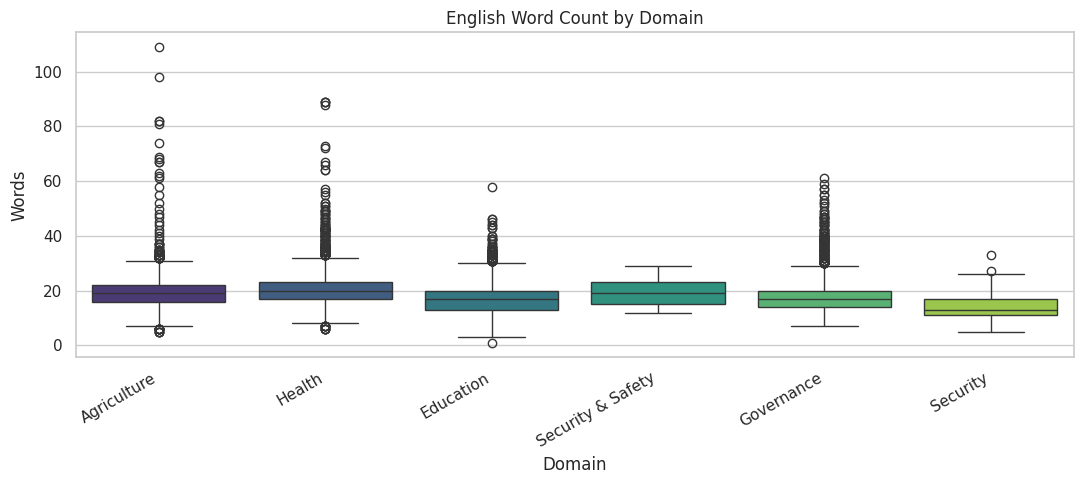

,mean,median,std
Domain,,,
Health,20.7,20.0,6.2
Agriculture,19.5,19.0,5.7
Security & Safety,19.0,19.0,4.4
Governance,17.9,17.0,6.0
Education,17.0,17.0,6.2
Security,13.8,13.0,4.3


In [14]:
fig, ax = plt.subplots(figsize=(11,5))
sns.boxplot(data=df, x='Domain', y='English_word_count', ax=ax, palette='viridis')
ax.set_title('English Word Count by Domain')
ax.set_ylabel('Words')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df.groupby('Domain')['English_word_count'].agg(['mean','median','std']).round(1).sort_values('mean', ascending=False)

**Interpretation:** Message length varies modestly by domain. Domains dealing with **procedural or regulatory announcements** (e.g., Governance) tend to run slightly longer, likely because they need to specify institutions, dates, or policy names, while more direct behavioral-nudge domains may be more terse. The differences are not dramatic, suggesting a broadly consistent PSA "house style" was applied across domains during content creation.

## 7. Vocabulary & Word Frequency Analysis (English)

In [15]:
STOPWORDS = set("the a an is are was were be been being of to and in on at for with by from as it its this that these those their they them he she his her will shall should would can could may might not no do does did has have had".split())

def tokenize(text):
    return re.findall(r"[a-zA-Z']+", str(text).lower())

all_tokens = [tok for text in df['English'] for tok in tokenize(text)]
content_tokens = [t for t in all_tokens if t not in STOPWORDS and len(t) > 2]

print(f"Total tokens: {len(all_tokens):,}")
print(f"Unique tokens (vocabulary size): {len(set(all_tokens)):,}")
print(f"Content tokens (stopwords removed): {len(content_tokens):,}")

top_words = Counter(content_tokens).most_common(20)
pd.DataFrame(top_words, columns=['word','count'])

Total tokens: 396,720
Unique tokens (vocabulary size): 10,252
Content tokens (stopwords removed): 289,907


,word,count
0,county,16419
1,public,3812
2,residents,3789
3,notice,3733
4,health,3588
5,kenya,3554
6,reminds,3471
7,urges,2684
8,free,2568
9,farmers,2524


/tmp/ipykernel_601/4043390635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=ax, palette='mako')


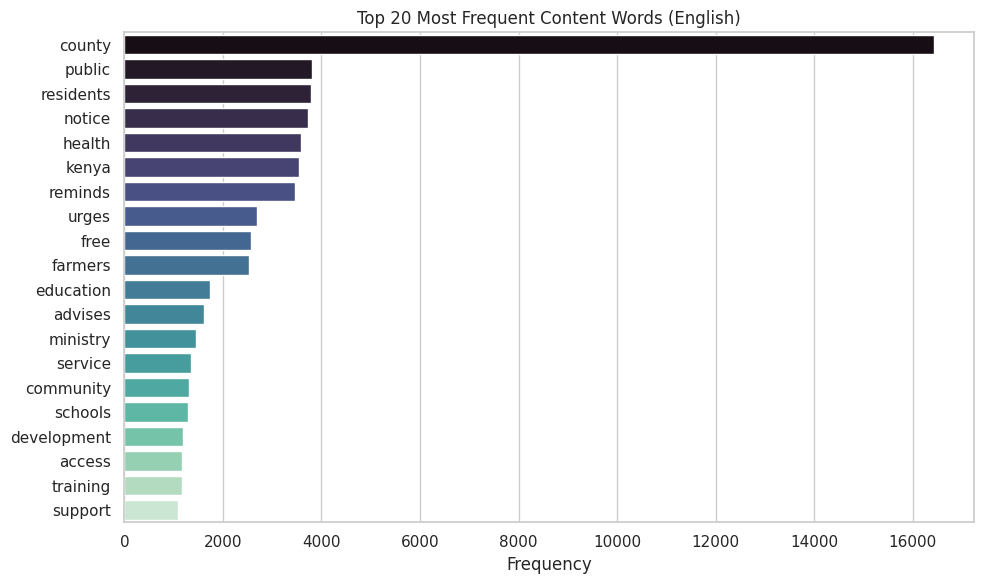

In [16]:
words, counts = zip(*top_words)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), ax=ax, palette='mako')
ax.set_title('Top 20 Most Frequent Content Words (English)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** The most frequent content words (e.g., terms like "encouraged," "farmers," "kenya," "urged") reflect the PSA genre's characteristic **call-to-action register** — messages consistently urge, encourage, or notify citizens rather than simply reporting facts. The prominence of institutional/government-related terms confirms these are official public communications rather than casual news. This vocabulary profile would be useful context if building a text classifier: action-oriented verbs may be weak domain signals (they appear across all domains), while nouns (crop names, disease names, institution names) are likely the stronger discriminative features between domains.

## 8. Distinctive Vocabulary per Domain

/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')
/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')


/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')
/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')
/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')


/tmp/ipykernel_601/1210499530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')


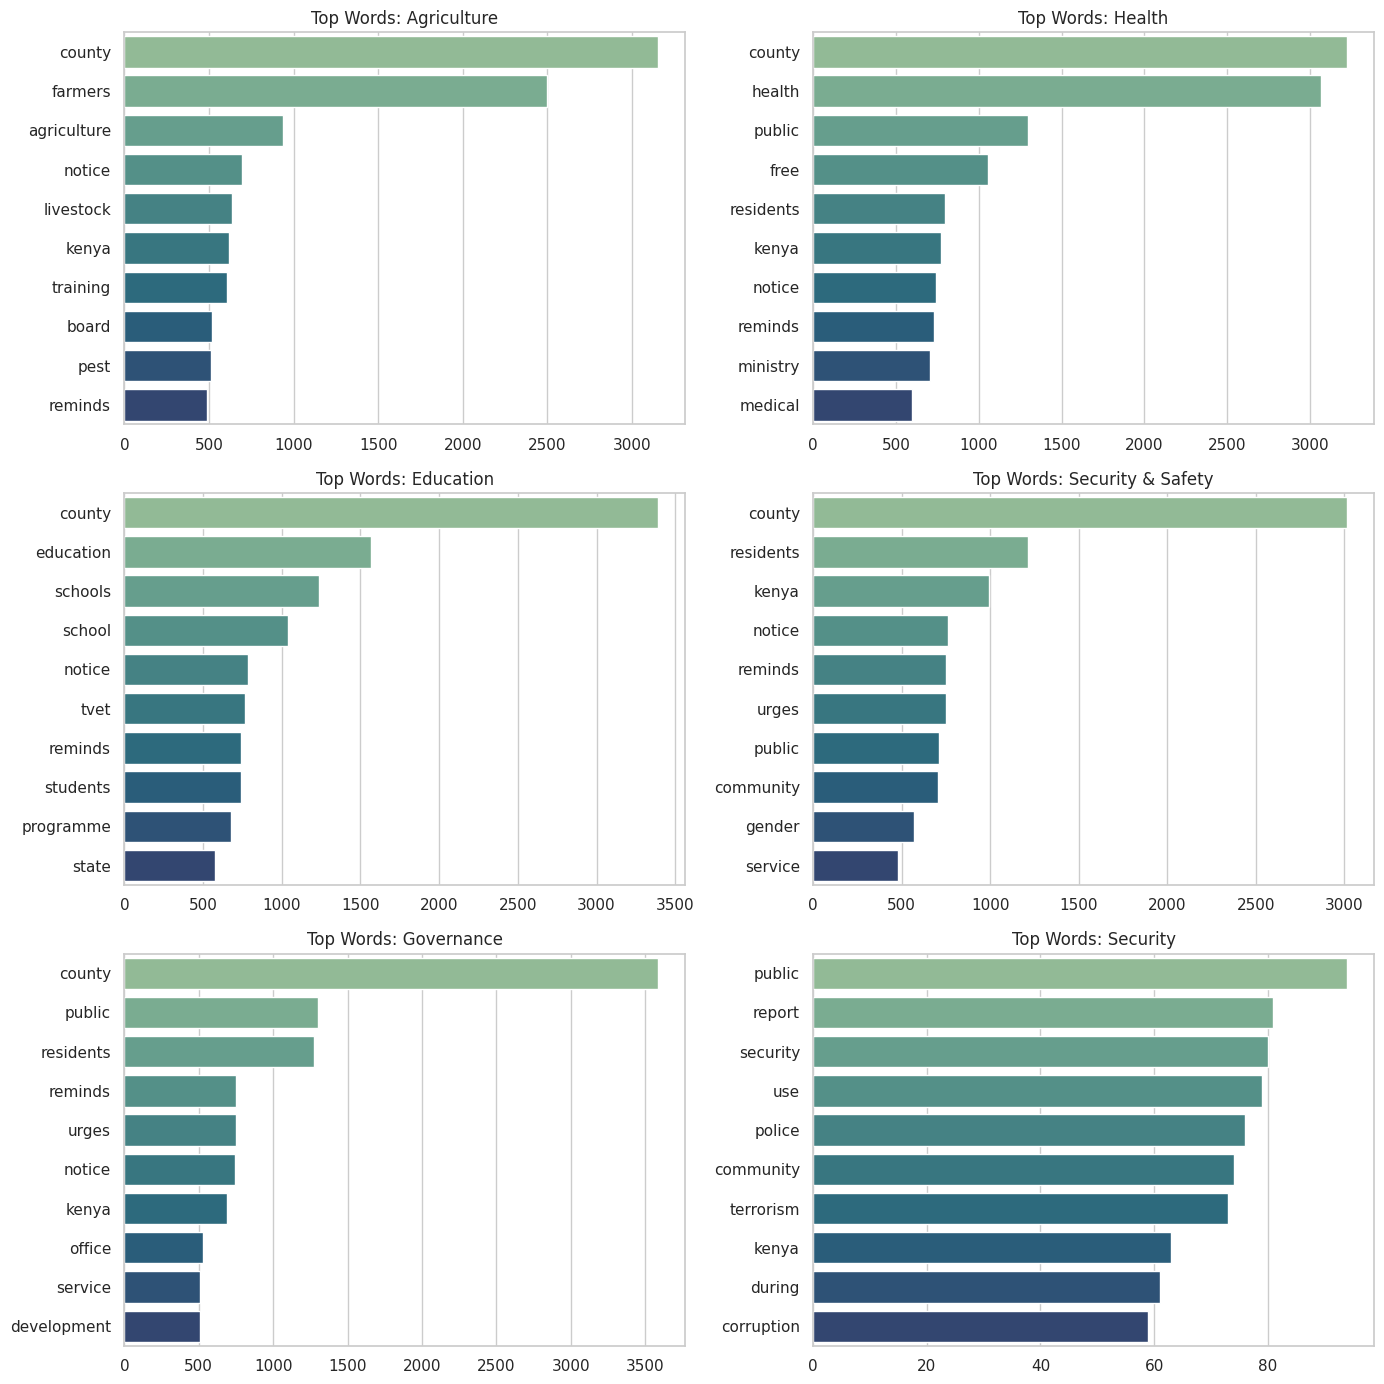

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, dom in enumerate(df['Domain'].unique()):
    dom_tokens = [tok for text in df[df['Domain']==dom]['English'] for tok in tokenize(text)
                  if tok not in STOPWORDS and len(tok) > 2]
    top = Counter(dom_tokens).most_common(10)
    if not top:
        continue
    w, c = zip(*top)
    sns.barplot(x=list(c), y=list(w), ax=axes[i], palette='crest')
    axes[i].set_title(f'Top Words: {dom}')

plt.tight_layout()
plt.show()

**Interpretation:** Each domain has a clearly distinguishable vocabulary fingerprint — e.g. Agriculture messages cluster around farming/crop/livestock terms, Health around disease/clinic/vaccination terms, and Education around school/students/curriculum terms. This strong lexical separability is a good sign for any future text-classification model: domain labels appear well-aligned with genuinely distinct topical content, not just arbitrary tagging.

## 9. Cross-Language Length Correlation

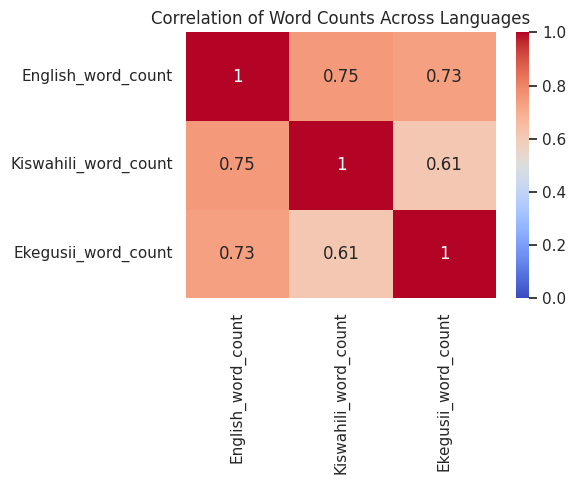

,English_word_count,Kiswahili_word_count,Ekegusii_word_count
English_word_count,1.000000,0.749646,0.734094
Kiswahili_word_count,0.749646,1.000000,0.613681
Ekegusii_word_count,0.734094,0.613681,1.000000


In [18]:
corr = df[['English_word_count','Kiswahili_word_count','Ekegusii_word_count']].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation of Word Counts Across Languages')
plt.tight_layout()
plt.show()
corr

**Interpretation:** Word counts across the three languages are **strongly positively correlated**, confirming that longer English source messages reliably produce longer translations in both target languages. This is a useful sanity check for translation-alignment quality: a weak or negative correlation would have suggested systemic misalignment between rows/columns.

## 10. Summary of Key Findings

1. **Clean, low-missingness dataset:** Only 3 of 21,306 rows (0.01%) have a missing value, all in the `Kiswahili` column.
2. **`PSA_ID` is not a global primary key** — it's scoped per domain. The composite key **(`PSA_ID`, `Domain`)** is unique and should be used for any joins or lookups.
3. **Domain distribution is imbalanced**: Education, Agriculture, and Health dominate (~65% of rows combined), while `Security` (4.7%) is comparatively small and likely overlaps semantically with `Security & Safety` — a strong candidate for label consolidation.
4. **No duplicate PSA text** — every English message is unique, indicating minimal redundancy in content.
5. **Kiswahili and Ekegusii translations run longer than English** on average (~15–20% more words), consistent with the grammatical structure of Bantu languages, and this holds up at the per-row level (ratio distributions centered just above 1.0), with a small set of outlier rows worth manual QA.
6. **Vocabulary is highly domain-distinctive**, supporting the validity of the domain labels for downstream text classification tasks.
7. **Word counts correlate strongly across all three languages**, suggesting good translation alignment quality overall.

### Suggested Next Steps
- Manually review the flagged length-ratio outlier rows for translation QA.
- Consider merging `Security` and `Security & Safety` into one label before training a classifier.
- If building an NLP model (classification or MT), use (`PSA_ID`, `Domain`) as the unique row key rather than `PSA_ID` alone.
- Consider TF-IDF or embedding-based analysis as a follow-up to quantify domain separability more rigorously than raw word-frequency counts.
